In [1]:
import pandas as pd
import seaborn as sns
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append('../../scripts/signals_analysis')

from calculate import get_signals, log2fc
from save import save_signals

sys.path.append('../../scripts/coordinates_analysis')

from compare import compare_pairwise

## OPTION 1) **IAA/DMSO:** Plot log2fold change for peaks from DMSO/IAA experiment
Plot scatterplot without coloring points (peaks) which are overlapped with factor

In [ ]:
output_dir = '../../results/scatterplots' # where plots are saved

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
######### use cmd + shift + F to replace strain name ##########

# Paste outputs from notebooks/3_signals/calculate_signals.ipynb
DMSO_signals = pd.read_csv('../../results/signals/spikein_mean/RDY466_as_DMSO_25_nC_spikein.csv', sep='\t', header=None)
IAA_signals = pd.read_csv('../../results/signals/spikein_mean/RDY466_as_IAA_25_nC_spikein.csv', sep='\t', header=None)
plot_name = 'RDY466_as'

In [96]:
# Calculate log2fc
fc = pd.DataFrame()
fc['log2FC'] = log2fc(IAA_df=IAA_signals,
                     DMSO_df=DMSO_signals)

# Add info about peak signal in DMSO sample
fc['DMSO'] = DMSO_signals.sum(axis=0)

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_46069/393928889.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=14)
/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_46069/393928889.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


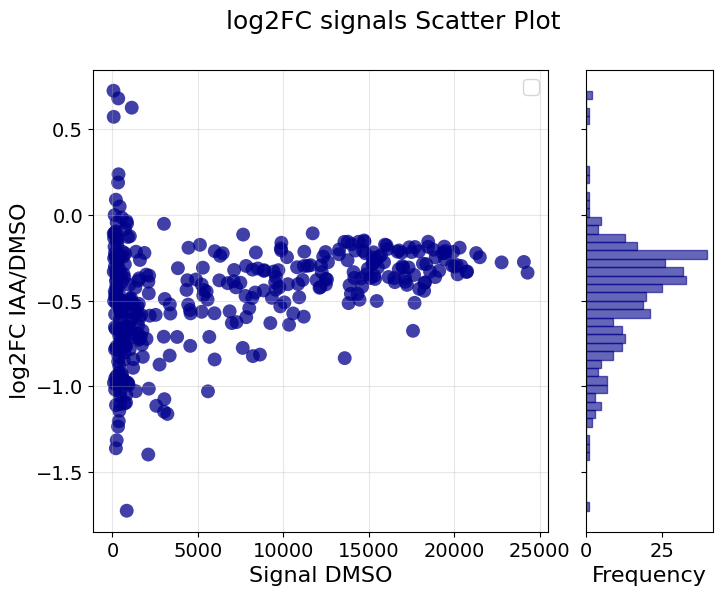

In [ ]:
# Set global font size
plt.rcParams.update({'font.size': 16})

fig = plt.figure(figsize=(8, 6))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)
ax = fig.add_subplot(grid[0:4, 0:3])

# Histogram on right
hist_right_ax = fig.add_subplot(grid[0:4, 3], sharey=ax)

# Plot scatter for two sets of datapoints - added more points by adjusting alpha and size
ax.scatter(
    fc['DMSO'],
    fc['log2FC'],
    color=f'{color}',
    alpha=0.75,  # Reduced alpha for better visibility with more points
    s=100,       # Point size
    edgecolors='none'  # Remove edges
)

## LABELS ##
ax.set_xlabel('Signal DMSO', fontsize=16)
ax.set_ylabel('log2FC IAA/DMSO', fontsize=16)
ax.legend(loc='upper right', fontsize=14)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=14)

# Right histogram
hist_right_ax.hist(fc['log2FC'], bins=50, alpha=0.6, color=f'{color}', 
                   edgecolor=f'{color}', orientation='horizontal')
hist_right_ax.set_xlabel('Frequency', fontsize=16)
hist_right_ax.tick_params(axis='both', which='major', labelsize=14)
plt.setp(hist_right_ax.get_yticklabels(), visible=False)

plt.suptitle('log2FC signals Scatter Plot', fontsize=18)
plt.tight_layout()

# Save figure with meaningful name
plt.savefig(f'{output_dir}/{plot_name}_scatter.png', dpi=300, bbox_inches='tight')

## OPTION 2) **IAA/DMSO:** Plot log2fold change for peaks from DMSO/IAA experiment
Plot scatterplot WITH coloring points (peaks) which are overlapped with factor

In [2]:
output_dir = '../../results/scatterplots' # where plots are saved

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
######### use cmd + shift + F to replace strain name ##########

# Paste outputs from notebooks/3_signals/calculate_signals.ipynb
DMSO_signals = pd.read_csv('../../results/signals/spikein_mean/RDY466_as_DMSO_25_nC_spikein.csv', sep='\t', header=None)
IAA_signals = pd.read_csv('../../results/signals/spikein_mean/RDY466_as_IAA_25_nC_spikein.csv', sep='\t', header=None)
plot_name = 'RDY466_as'

# To label peaks by overlapping with other peaks (e.g. ARS, MCM), add coordinates of them in .bed format

# 1. Paste output from notebooks/2_comparative/compare_peaks.ipynb
DMSO_IAA_coord = '../../results/compared_peaks/RDY466_as_DMSO_25_nC_RDY466_as_IAA_25_nC/in_RDY466_as_IAA_25_nC_RDY466_as_DMSO_25_nC_ex.bed'
# 2. Factor by which points will be labeled
factor_coord = '../../resources/ARS_late.bed'
factor_name = 'ARS late'



In [4]:
######### LABEL PEAKS #######
# Load .bed files
factor = pd.read_csv(factor_coord, names=['chr', 'start', 'end', 'center'], sep='\t')
DMSO_IAA = pd.read_csv(DMSO_IAA_coord, names=['chr', 'start', 'end', 'center'], sep='\t')

# Get peaks common for DMSO & IAA that only overlapping with factor
factor_DMSO_IAA = compare_pairwise({'factor': factor},
                                    {'DMSO_IAA': DMSO_IAA})

# Filter unnessary columns
coord = factor_DMSO_IAA.drop(factor_DMSO_IAA.columns[[1, 2, 3]], axis=1).dropna().reset_index(drop=True)
coord = coord.set_axis(['chr', 'start', 'end', 'center'], axis=1) # here only DMSOvsIAA peaks overlapping with factor

# Calculate log2fc
fc = pd.DataFrame()
fc['log2FC'] = log2fc(IAA_df=IAA_signals,
                     DMSO_df=DMSO_signals)

# Add info about peak signal in DMSO sample
fc['DMSO'] = DMSO_signals.sum(axis=0)

# Add label for each peak/row. 1 - is overlpaping with factor; 0 - is not.
fc['factor'] = (
    DMSO_IAA['center'].isin(coord['center'])
).astype(int)

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_12684/358014266.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


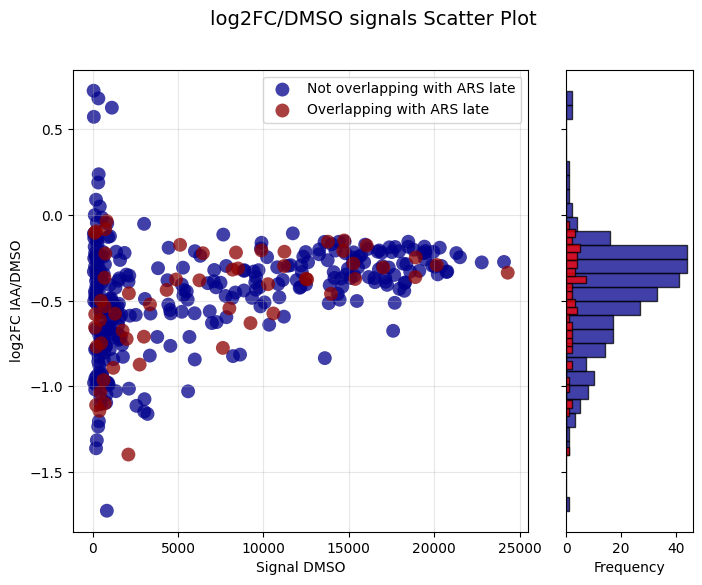

In [13]:
overlap_1 = fc[fc['factor'] == 1]
overlap_0 = fc[fc['factor'] == 0]


fig = plt.figure(figsize=(8, 6))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)
ax = fig.add_subplot(grid[0:4, 0:3])

# Histogram on right
hist_right_ax = fig.add_subplot(grid[0:4, 3], sharey=ax)

# Plot scatter for two sets of datapoints
ax.scatter(
    overlap_0['DMSO'],
    overlap_0['log2FC'],
    color='darkblue', # change color here for not overlap. points
    alpha=0.75,
    s=100,       # Point size
    edgecolors='none',  # Remove edges
    label=f'Not overlapping with {factor_name}'
)
ax.scatter(
    overlap_1['DMSO'],
    overlap_1['log2FC'],
    color='darkred', # change color here for overlap. points
    alpha=0.75,
    s=100,       # Point size
    edgecolors='none',  # Remove edges
    label=f'Overlapping with {factor_name}'
)

## LABELS ##
ax.set_xlabel('Signal DMSO')
ax.set_ylabel('log2FC IAA/DMSO')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Change scale if needed
#ax.set_xscale('log')

# Right histogram
hist_right_ax.hist(overlap_0['log2FC'], bins=30, alpha=0.75, color='darkblue', # change color here for not overlap. points
                   edgecolor='black', orientation='horizontal')
hist_right_ax.set_xlabel('Frequency')
hist_right_ax.hist(overlap_1['log2FC'], bins=30, alpha=0.75, color='red', # change color here for overlap. points
                   edgecolor='black', orientation='horizontal')
plt.setp(hist_right_ax.get_yticklabels(), visible=False)

plt.suptitle('log2FC/DMSO signals Scatter Plot', fontsize=14)
plt.tight_layout()

# Save figure with meaningful name
plt.savefig(f'{output_dir}/{plot_name}_scatter_{factor_name}.png', dpi=300, bbox_inches='tight')
